In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df = pd.read_csv('dataframe_MG.csv')

# Selecionar as variáveis
features = ['ln_Mi', 'ln_Mj', 'ln_Dij', 'ln_VL_FOB_KG', 'MESMA_UF', 'PORTO_SANTOS', 'ALTA_PRODUCAO']
X = df[features]
y = df['ln_Tij']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinar o modelo MLP
mlp = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Previsões
y_pred = mlp.predict(X_test_scaled)

# Avaliação
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 0.93
RMSE: 1.34
R²: 0.8470


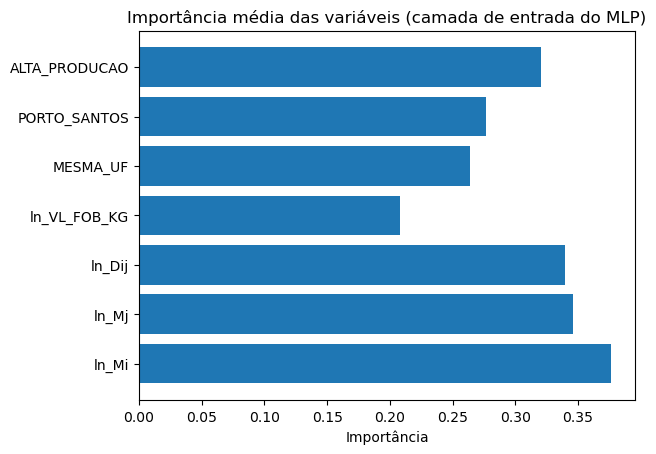

In [2]:
import matplotlib.pyplot as plt

importances = np.abs(mlp.coefs_[0]).mean(axis=1)
plt.barh(features, importances)
plt.title("Importância média das variáveis (camada de entrada do MLP)")
plt.xlabel("Importância")
plt.show()

In [3]:
for seed in range(15):
    mlp = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=seed)
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_test_scaled)
    print(f"Seed {seed} | R²: {r2_score(y_test, y_pred):.4f}")

Seed 0 | R²: 0.8502
Seed 1 | R²: 0.8505
Seed 2 | R²: 0.8474
Seed 3 | R²: 0.8470
Seed 4 | R²: 0.8499
Seed 5 | R²: 0.8453
Seed 6 | R²: 0.8422
Seed 7 | R²: 0.8478
Seed 8 | R²: 0.8491
Seed 9 | R²: 0.8472
Seed 10 | R²: 0.8447
Seed 11 | R²: 0.8444
Seed 12 | R²: 0.8483
Seed 13 | R²: 0.8485
Seed 14 | R²: 0.8451


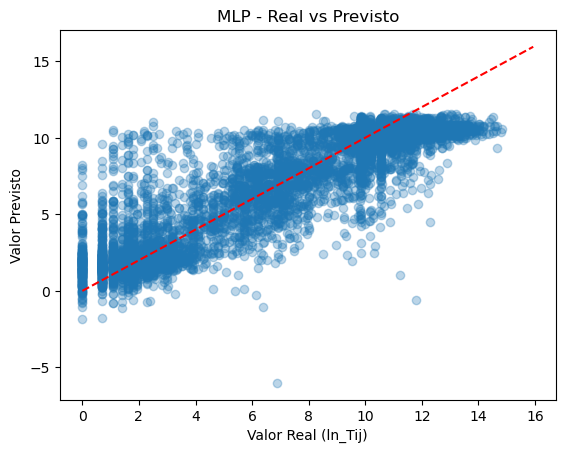

In [4]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Valor Real (ln_Tij)")
plt.ylabel("Valor Previsto")
plt.title("MLP - Real vs Previsto")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.savefig('mlpvsreal.png')
plt.show()

In [ ]:
# Solicita o município
mun = str(input('Digite o município desejado: '))

# Filtra o dataframe
pes = df[df['CO_MUN'] == mun]

# Verifica se o município existe
if pes.empty:
    print("Município não encontrado no dataframe.")
else:
    # Obtém os valores mais frequentes para aquele município
    ln_Mix = pes['ln_Mi'].mode()[0]	
    ln_Mjx = pes['ln_Mj'].mode()[0]
    lnDijx = pes['ln_Dij'].mode()[0]
    ln_VL_FOB_KGx = pes['ln_VL_FOB_KG'].mode()[0]
    MESMA_UFx = pes['MESMA_UF'].mode()[0]
    PORTO_SANTOSx = pes['PORTO_SANTOS'].mode()[0]
    ALTA_PRODUCAOx = pes['ALTA_PRODUCAO'].mode()[0]

    # Cria o vetor de entrada
    nova_entrada = np.array([[ln_Mix, ln_Mjx, lnDijx, ln_VL_FOB_KGx, MESMA_UFx, PORTO_SANTOSx, ALTA_PRODUCAOx]])
    
    # Normaliza a entrada com o scaler treinado
    nova_entrada_scaled = scaler.transform(nova_entrada)
    
    # Faz a previsão
    pred_log = mlp.predict(nova_entrada_scaled)[0]
    pred_kg = np.exp(pred_log)

    print(f"\nPrevisão para {mun} em Jan/2026:")
    print(f"- ln(KG_LIQUIDO): {pred_log:.2f}")
    print(f"- KG_LIQUIDO estimado: {pred_kg:.0f} kg")